# Sparse-Network Milestone, Step 1: inducing hidden-layer sparsity

Every model here is a **2-hidden-layer SLAYER SNN** trained on SHD `whole` with
learnable axonal delays (SGD-delay), under the **fixed-weight** protocol: training
runs on *clean* data and the sparsity penalty acts only on the **1st hidden
layer**'s firing. The jitter that measures temporal processing is applied at
evaluation only, by a separate script — none of it is in these figures.

The figures read `jitter/log/*_training_log.json` directly, so they update as more
runs finish. That folder currently mixes the three calibration attempts the
progress log records, and the notebook separates them by what the logs show rather
than by file name — a run's warm-up length is recovered from its own curves, since
the penalty is off for exactly as long as the logged total loss equals the task
loss:

- **plain L1** (`lam*`) — attempt 1: collapses at every λ;
- **hinge behind a clean warm-up** (`tgt*`, penalty engaging at epoch 100) —
  attempt 2: no collapse, but no sparsity either;
- **hinge from epoch 0** (`tgt3_str*`) — the resolved recipe, swept over strength.

Everything shown is a **seed-42 calibration run over 400 epochs**. The locked
15-model run (5 strengths × 3 seeds, 1250 epochs) has not been written to this
folder yet; the same cells will pick it up when it is.

Conventions used throughout:
- **Firing** is always mean spikes per hidden neuron per sample (`train_rate`, or
  `train_reg` in the older logs — the same quantity under a renamed key).
- The **dense anchor** (`lam0`, no penalty at all) is black dashed in every panel.
- Colour runs dark → bright with an increasing penalty coefficient.

In [1]:
import json
import pathlib
import re
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib.axes import Axes

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

# Training logs and the clean-test summary written by jitter/jitter_train.py.
LOG_DIR = pathlib.Path("jitter/log")
SUMMARY_PATH = LOG_DIR / "sparse_whole_delay_train_summary.json"

# Experiment constants, mirroring jitter_train.py.
NUM_CLASSES = 20
CHANCE_ACC = 100.0 / NUM_CLASSES     # 5% — SHD has 20 classes
HINGE_TARGET = 3.0                   # SPARSITY_TARGETS in the training script

# Shared visual conventions.
ANCHOR_STYLE = {"color": "black", "linestyle": "--", "linewidth": 1.6}
GRID_STYLE = {"linestyle": ":", "linewidth": 0.7, "alpha": 0.7}
REF_STYLE = {"color": "grey", "linestyle": ":", "linewidth": 1.2}
SMOOTH_WINDOW = 9                    # epochs, validation-accuracy moving average

RUN_PATTERN = re.compile(
    r"^sparse_whole_delay_(?P<tag>.+)_seed(?P<seed>\d+)_training_log\.json$"
)


@dataclass
class Run:
    """One trained model: what its file name says about how it was penalised."""

    tag: str
    seed: int
    path: pathlib.Path
    penalty: str                    # "none" | "l1" | "hinge"
    lam: float | None = None        # plain-L1 coefficient
    target: float | None = None     # hinge target firing rate
    strength: float | None = None   # hinge penalty coefficient


@dataclass
class Curves:
    """Per-epoch training curves of a single run, on a common schema.

    The firing series is read from ``train_rate`` when present and from the older
    ``train_reg`` key otherwise; both hold the same quantity (mean spikes per
    hidden neuron per sample) — the key was renamed mid-experiment.
    """

    epoch: np.ndarray
    rate: np.ndarray                # mean spikes / hidden neuron / sample
    task_loss: np.ndarray           # NumSpikes loss, penalty excluded
    val_acc: np.ndarray             # percent
    delay: np.ndarray               # mean learned delay, time steps
    warmup_epochs: int | None       # epoch the penalty engaged, None if never


def parse_run(path: pathlib.Path) -> Run | None:
    """Parse a training-log file name into a :class:`Run`.

    Recognises the two penalty families run so far: ``lam{value}`` (plain L1,
    where ``lam0`` means no penalty at all) and ``tgt{target}[_str{strength}]``
    (hinge toward a target firing rate).

    Args:
        path: Path to a ``*_training_log.json`` file.

    Returns:
        The parsed run, or ``None`` if the name does not match the convention.
    """
    match = RUN_PATTERN.match(path.name)
    if match is None:
        return None
    tag = match.group("tag")
    seed = int(match.group("seed"))

    if tag.startswith("lam"):
        lam = float(tag[len("lam"):])
        penalty = "none" if lam == 0 else "l1"
        return Run(tag, seed, path, penalty, lam=lam)

    if tag.startswith("tgt"):
        parts = tag.split("_str")
        target = float(parts[0][len("tgt"):])
        strength = float(parts[1]) if len(parts) > 1 else None
        return Run(tag, seed, path, "hinge", target=target, strength=strength)

    return None


def load_curves(run: Run) -> Curves:
    """Read one training log and normalise it onto the :class:`Curves` schema.

    The warm-up length is recovered from the data rather than assumed: the
    penalty is off for as long as the logged total loss equals the task loss, so
    the first epoch at which they differ is the epoch the penalty engaged.

    Args:
        run: The run whose log should be read.

    Returns:
        The run's curves, with ``warmup_epochs`` set to ``None`` when the penalty
        never contributed (an unpenalised run).
    """
    with open(run.path) as fh:
        raw = json.load(fh)

    rate_key = "train_rate" if "train_rate" in raw else "train_reg"
    total_loss = np.array(raw["train_loss"])
    task_loss = np.array(raw["train_task_loss"])
    engaged = np.flatnonzero(np.abs(total_loss - task_loss) > 0)

    return Curves(
        epoch=np.array(raw["epoch"]),
        rate=np.array(raw[rate_key]),
        task_loss=task_loss,
        val_acc=np.array(raw["val_acc"]) * 100.0,
        delay=np.array(raw["delay_mean"]),
        warmup_epochs=int(engaged[0]) if engaged.size else None,
    )


def discover_runs(log_dir: pathlib.Path = LOG_DIR) -> list[Run]:
    """Return every parseable run under ``log_dir``, sorted by file name."""
    runs = [parse_run(path) for path in sorted(log_dir.glob("*_training_log.json"))]
    return [run for run in runs if run is not None]


def load_summary(path: pathlib.Path = SUMMARY_PATH) -> dict[str, dict]:
    """Load the clean test-set summary table, or ``{}`` if it does not exist."""
    if not path.exists():
        return {}
    with open(path) as fh:
        return json.load(fh)


# Catalogue of everything in the log folder, read once and shared by the figures.
RUNS = discover_runs()
CURVES = {run.tag: load_curves(run) for run in RUNS}
SUMMARY = load_summary()


def has_warmup(run: Run) -> bool:
    """True if the run's penalty engaged only after some clean warm-up epochs."""
    warmup = CURVES[run.tag].warmup_epochs
    return warmup is not None and warmup > 0


def select_runs(penalty: str, warmed_up: bool | None = None) -> list[Run]:
    """Filter the catalogue by penalty family and, optionally, by warm-up.

    Args:
        penalty: ``"none"``, ``"l1"`` or ``"hinge"``.
        warmed_up: ``True`` keeps only runs whose penalty engaged after a warm-up,
            ``False`` only those penalised from epoch 0, ``None`` keeps both.

    Returns:
        The matching runs, ordered by their penalty coefficient.
    """
    selected = [run for run in RUNS if run.penalty == penalty]
    if warmed_up is not None:
        selected = [run for run in selected if has_warmup(run) == warmed_up]
    sort_keys = {
        "l1": lambda run: run.lam,
        "hinge": lambda run: (run.strength or 0.0, run.target or 0.0),
    }
    return sorted(selected, key=sort_keys.get(penalty, lambda run: run.tag))


def anchor_run() -> tuple[str, Curves] | None:
    """Return the unpenalised dense-anchor run as a ``(label, curves)`` pair."""
    unpenalised = select_runs("none")
    if not unpenalised:
        return None
    return "no penalty (dense anchor)", CURVES[unpenalised[0].tag]


def index_colors(count: int) -> list[tuple]:
    """Return ``count`` colours from the same ramp as :func:`sweep_colors`."""
    return [plt.cm.viridis(position)
            for position in np.linspace(0.12, 0.88, max(count, 1))]


def hinge_label(run: Run, show_target: bool = False) -> str:
    """Legend label for a hinge run.

    Args:
        run: The run to label.
        show_target: Include the target firing rate, for figures whose runs do
            not all share one target.

    Returns:
        A label such as ``"strength 0.01"`` or ``"target 8, default strength"``.
    """
    strength = ("default strength" if run.strength is None
                else f"strength {run.strength:g}")
    return f"target {run.target:g}, {strength}" if show_target else strength


def build_series(
    runs: list[Run],
    labeller,
    colors: list[tuple],
    linestyle: str = "-",
    linewidths: list[float] | None = None,
) -> list[tuple[str, Curves, dict]]:
    """Assemble the ``(label, curves, style)`` triples a figure plots.

    Args:
        runs: Runs to draw, already in legend and colour order.
        labeller: Callable mapping a run to its legend label.
        colors: One colour per run, in the same order.
        linestyle: Line style shared by the whole series.
        linewidths: Optional per-run line widths. Useful when curves coincide
            exactly and would otherwise hide each other.

    Returns:
        One triple per run, ready for :func:`plot_training_grid`.
    """
    widths = linewidths if linewidths is not None else [1.6] * len(runs)
    return [
        (labeller(run), CURVES[run.tag],
         {"color": color, "linestyle": linestyle, "linewidth": width})
        for run, color, width in zip(runs, colors, widths)
    ]


def smooth(values: np.ndarray, window: int) -> np.ndarray:
    """Centred moving average that preserves the input length.

    Args:
        values: 1-D series to smooth.
        window: Window length in samples; ``<= 1`` returns the input unchanged.

    Returns:
        The smoothed series, same shape as ``values``.
    """
    if window <= 1 or values.size < window:
        return values
    half = window // 2
    padded = np.pad(values, half, mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(padded, kernel, mode="same")[half: half + values.size]


# (attribute, axis label, panel title) for the 2x2 training-curve grid.
PANELS = [
    ("rate", "Spikes / neuron / sample", "1st hidden layer firing"),
    ("val_acc", "Validation accuracy (%)",
     f"Validation accuracy ({SMOOTH_WINDOW}-epoch moving avg.)"),
    ("task_loss", "NumSpikes loss", "Training task loss (penalty excluded)"),
    ("delay", "Mean delay (time steps)", "Learned axonal delays"),
]


def _draw_reference_line(ax: Axes, attribute: str) -> None:
    """Add the hinge target / chance-accuracy guide line where it applies."""
    guides = {"rate": (HINGE_TARGET, "target"), "val_acc": (CHANCE_ACC, "chance")}
    if attribute not in guides:
        return
    value, text = guides[attribute]
    ax.axhline(value, **REF_STYLE)
    ax.text(0.99, value, f" {text}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=8, color="grey", style="italic")


def _draw_panel(
    ax: Axes,
    attribute: str,
    series: list[tuple[str, Curves, dict]],
    anchor: tuple[str, Curves] | None,
) -> None:
    """Draw one metric for the anchor and every run in ``series`` onto ``ax``."""
    entries = list(series)
    if anchor is not None:
        entries = [(anchor[0], anchor[1], ANCHOR_STYLE)] + entries

    for label, curves, style in entries:
        values = getattr(curves, attribute)
        if attribute == "val_acc":
            values = smooth(values, SMOOTH_WINDOW)
        ax.plot(curves.epoch, values, label=label, **{"linewidth": 1.6, **style})

    _draw_reference_line(ax, attribute)
    ax.set_xlabel("Epoch")
    ax.grid(True, **GRID_STYLE)


def plot_training_grid(
    series: list[tuple[str, Curves, dict]],
    suptitle: str,
    anchor: tuple[str, Curves] | None = None,
    warmup_marker: int | None = None,
) -> None:
    """Plot the four training curves of a set of runs as a 2x2 grid.

    Args:
        series: ``(label, curves, line-style kwargs)`` per run, in legend order.
        suptitle: Figure title.
        anchor: Optional unpenalised reference run, drawn dashed in every panel.
        warmup_marker: If given, mark this epoch in every panel as the moment the
            penalty engaged.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

    for ax, (attribute, ylabel, title) in zip(axes.ravel(), PANELS):
        _draw_panel(ax, attribute, series, anchor)
        if warmup_marker is not None:
            ax.axvline(warmup_marker, color="crimson", linestyle="-.",
                       linewidth=1.0, alpha=0.7)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if warmup_marker is not None:
        handles.append(mlines.Line2D([], [], color="crimson", linestyle="-.",
                                     linewidth=1.0, alpha=0.7))
        labels.append(f"penalty engages (epoch {warmup_marker})")

    fig.suptitle(suptitle, fontsize=15)
    fig.legend(handles, labels, loc="lower center", frameon=False,
               ncol=min(len(labels), 3), bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout(rect=(0, 0.02, 1, 0.96))
    plt.show()


def achieved_rate(curves: Curves, last_epochs: int = 10) -> float:
    """Mean firing rate over the final ``last_epochs`` epochs of training."""
    return float(np.mean(curves.rate[-last_epochs:]))


def summary_row(run: Run) -> dict | None:
    """Return the clean test-set summary entry for a run, if it has one."""
    return SUMMARY.get(f"sparse_whole_delay_{run.tag}_seed{run.seed}")


def plot_sparsity_tradeoff(runs: list[Run], suptitle: str) -> None:
    """Plot what the penalty strength buys: less firing, at what accuracy cost.

    Firing is the train-time rate averaged over the last 10 epochs; accuracy is
    the best validation accuracy of the run. Where ``jitter_train.py`` also wrote
    a clean *test*-set row for the run, it is overlaid as a hollow marker so the
    two measurements can be compared.

    Args:
        runs: Hinge runs to place, ordered by penalty strength.
        suptitle: Figure title.
    """
    swept = [run for run in runs if run.strength is not None]
    colors = index_colors(len(swept))
    fig, (ax_rate, ax_acc) = plt.subplots(1, 2, figsize=(11, 4.4))

    rates = [achieved_rate(CURVES[run.tag]) for run in swept]
    ax_rate.plot([run.strength for run in swept], rates,
                 color="grey", linewidth=1.0, zorder=1)

    for run, rate, color in zip(swept, rates, colors):
        curves = CURVES[run.tag]
        ax_rate.plot(run.strength, rate, marker="o", markersize=8, color=color,
                     zorder=2)
        ax_acc.plot(rate, curves.val_acc.max(), marker="o", markersize=8,
                    color=color, zorder=2)
        ax_acc.annotate(f"{run.strength:g}", (rate, curves.val_acc.max()),
                        textcoords="offset points", xytext=(7, 4), fontsize=8,
                        color=color)

        row = summary_row(run)
        if row is not None:
            test_point = (row["spikes_per_neuron"], row["clean_acc"] * 100.0)
            ax_acc.plot([rate, test_point[0]], [curves.val_acc.max(), test_point[1]],
                        color="grey", linewidth=0.8, zorder=1)
            ax_acc.plot(*test_point, marker="o", markersize=8,
                        markerfacecolor="none", markeredgecolor=color,
                        markeredgewidth=1.6, zorder=2)

    anchor = anchor_run()
    if anchor is not None:
        dense_rate = achieved_rate(anchor[1])
        ax_rate.axhline(dense_rate, **ANCHOR_STYLE)
        ax_rate.text(0.98, dense_rate, "no penalty ", va="top", ha="right",
                     fontsize=8, transform=ax_rate.get_yaxis_transform(),
                     color="black")
        ax_acc.plot(dense_rate, anchor[1].val_acc.max(), marker="*",
                    markersize=15, color="black", linestyle="none", zorder=2)

    ax_rate.set_xscale("log")
    ax_rate.axhline(HINGE_TARGET, **REF_STYLE)
    ax_rate.text(0.02, HINGE_TARGET, " target", va="bottom", fontsize=8,
                 transform=ax_rate.get_yaxis_transform(), color="grey",
                 style="italic")
    ax_rate.set_xlabel("Hinge penalty strength")
    ax_rate.set_ylabel("Spikes / neuron / sample")
    ax_rate.set_title("Achieved sparsity vs penalty strength")
    ax_rate.grid(True, **GRID_STYLE)

    ax_acc.set_xlabel("Spikes / neuron / sample (achieved)")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_title("Accuracy vs achieved sparsity")
    ax_acc.margins(0.09)          # room for the point annotations
    ax_acc.grid(True, **GRID_STYLE)
    ax_acc.legend(
        handles=[
            mlines.Line2D([], [], color="grey", marker="o", linestyle="none",
                          markersize=8),
            mlines.Line2D([], [], color="grey", marker="o", linestyle="none",
                          markersize=8, markerfacecolor="none",
                          markeredgewidth=1.6),
            mlines.Line2D([], [], color="black", marker="*", linestyle="none",
                          markersize=13),
        ],
        labels=["best validation accuracy", "clean test accuracy",
                "no penalty (dense anchor)"],
        loc="lower right", framealpha=0.9, fontsize=8.5,
    )

    fig.suptitle(suptitle, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


def plot_warmup_comparison(suptitle: str) -> None:
    """Contrast hidden firing with and without a clean warm-up before the hinge.

    Left: runs whose penalty engaged only after a warm-up. Right: runs penalised
    from epoch 0. Both panels share a y-axis and carry the dense anchor, so it is
    visible that the warm-up leaves the network in a dense solution the additive
    hinge no longer escapes, while shaping firing from the start does separate the
    strengths.

    Args:
        suptitle: Figure title.
    """
    groups = [
        ("With clean warm-up", select_runs("hinge", warmed_up=True), True),
        ("Penalty from epoch 0", select_runs("hinge", warmed_up=False), False),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True)
    anchor = anchor_run()

    for index, (ax, (title, runs, warmed)) in enumerate(zip(axes, groups)):
        if anchor is not None:
            ax.plot(anchor[1].epoch, anchor[1].rate, label=anchor[0],
                    **ANCHOR_STYLE)

        for run, color in zip(runs, index_colors(len(runs))):
            curves = CURVES[run.tag]
            ax.plot(curves.epoch, curves.rate, color=color, linewidth=1.6,
                    label=hinge_label(run, show_target=warmed))
            if warmed:
                ax.axvline(curves.warmup_epochs, color="crimson",
                           linestyle="-.", linewidth=1.0, alpha=0.7)

        ax.axhline(HINGE_TARGET, **REF_STYLE)
        ax.set_xlabel("Epoch")
        ax.set_title(title)
        ax.grid(True, **GRID_STYLE)
        # One legend per panel, placed underneath it so no curve is covered.
        fig.legend(*ax.get_legend_handles_labels(), loc="upper center",
                   bbox_to_anchor=(0.28 + 0.5 * index, 0.11), ncol=2,
                   frameon=False, fontsize=8.5)

    axes[0].set_ylabel("Spikes / neuron / sample")
    axes[0].text(0.01, HINGE_TARGET, " target",
                 transform=axes[0].get_yaxis_transform(), ha="left",
                 va="bottom", fontsize=8, color="grey", style="italic")

    fig.suptitle(suptitle, fontsize=15)
    fig.tight_layout(rect=(0, 0.12, 1, 0.94))
    plt.show()


def print_run_inventory() -> None:
    """Print every run in the log folder with how it was penalised and its result.

    Provenance matters here because the folder mixes three calibration attempts:
    the columns make the warm-up and the penalty family explicit rather than
    leaving them encoded in the file name.
    """
    header = (f"{'run':<22}{'penalty':<9}{'coeff':>8}{'warm-up':>9}{'epochs':>8}"
              f"{'firing':>9}{'best val %':>12}{'clean test %':>14}")
    print(header)
    print("-" * len(header))

    for run in RUNS:
        curves = CURVES[run.tag]
        coefficient = run.lam if run.penalty == "l1" else run.strength
        coefficient_text = "-" if coefficient is None else f"{coefficient:g}"
        warmup_text = "-" if curves.warmup_epochs is None else str(curves.warmup_epochs)
        row = summary_row(run)
        test_text = "-" if row is None else f"{row['clean_acc'] * 100:.2f}"
        print(
            f"{run.tag:<22}{run.penalty:<9}{coefficient_text:>8}{warmup_text:>9}"
            f"{curves.epoch.size:>8}{achieved_rate(curves):>9.2f}"
            f"{curves.val_acc.max():>12.2f}{test_text:>14}"
        )

## 1. Hinge penalty from epoch 0 — the strength sweep

The penalty is `strength · relu(per-neuron rate − target)` on the 1st hidden layer,
with the target fixed at 3 spikes/neuron and the penalty active from the first
epoch. Firing separates monotonically by strength (≈11 → ≈3, a ~3.5× spread) with
no collapse, while validation accuracy stays within a few points of the
unpenalised anchor. Note that firing plateaus *above* the target in every run: the
target is not the binding control here, the strength is.

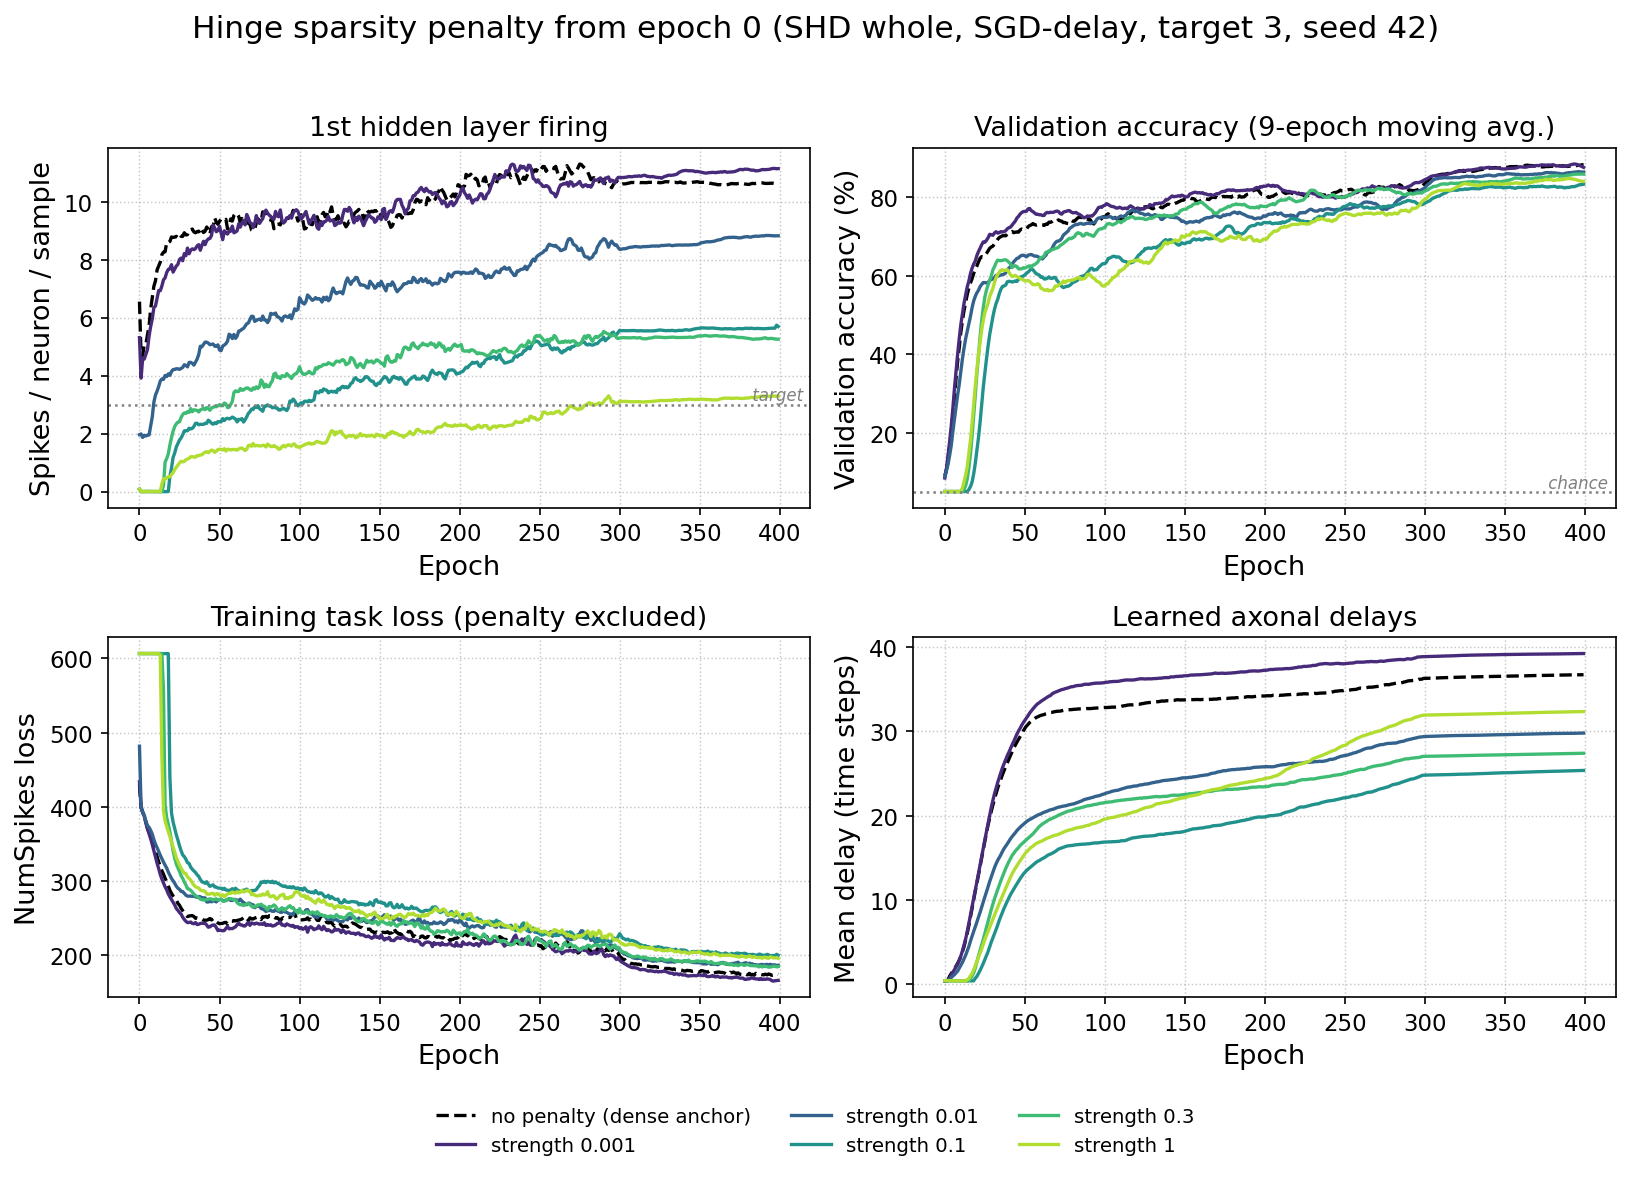

In [2]:
sweep = select_runs("hinge", warmed_up=False)

plot_training_grid(
    series=build_series(sweep, hinge_label, index_colors(len(sweep))),
    suptitle=(
        "Hinge sparsity penalty from epoch 0 "
        "(SHD whole, SGD-delay, target 3, seed 42)"
    ),
    anchor=anchor_run(),
)

## 2. What the strength buys

**Left:** achieved firing — the training rate averaged over the last 10 epochs —
against the penalty strength. This *measured* rate, not the coefficient, is the
axis the later sparsity-vs-temporal-processing analysis is run against; the map
between them is nonlinear and seed-dependent.

**Right:** accuracy against that achieved firing. Filled markers are the best
validation accuracy reached during training; hollow markers are the clean **test**
accuracy recorded in `sparse_whole_delay_train_summary.json` for the same run
(only the three most recent runs have one), joined to their validation point by a
grey line.

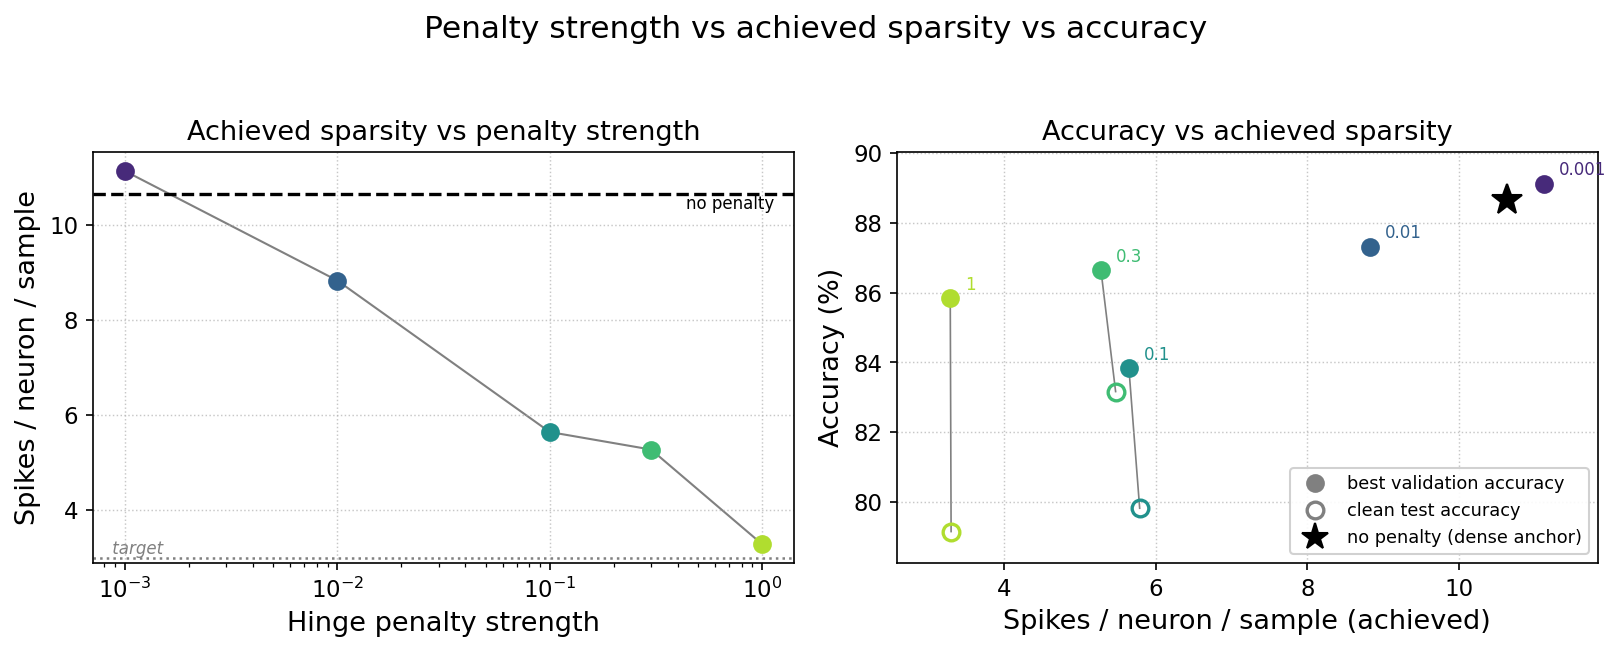

In [3]:
plot_sparsity_tradeoff(
    sweep,
    suptitle="Penalty strength vs achieved sparsity vs accuracy",
)

## 3. Why the clean warm-up was dropped

The same hinge penalty, but engaged only after 100 clean epochs (**left**) versus
from epoch 0 (**right**). After a warm-up the network sits in a dense solution the
additive hinge never escapes — firing tracks the anchor and only ever rises, at
either target and regardless of strength. Shaping firing from the start is what
produces the gradient in the right-hand panel.

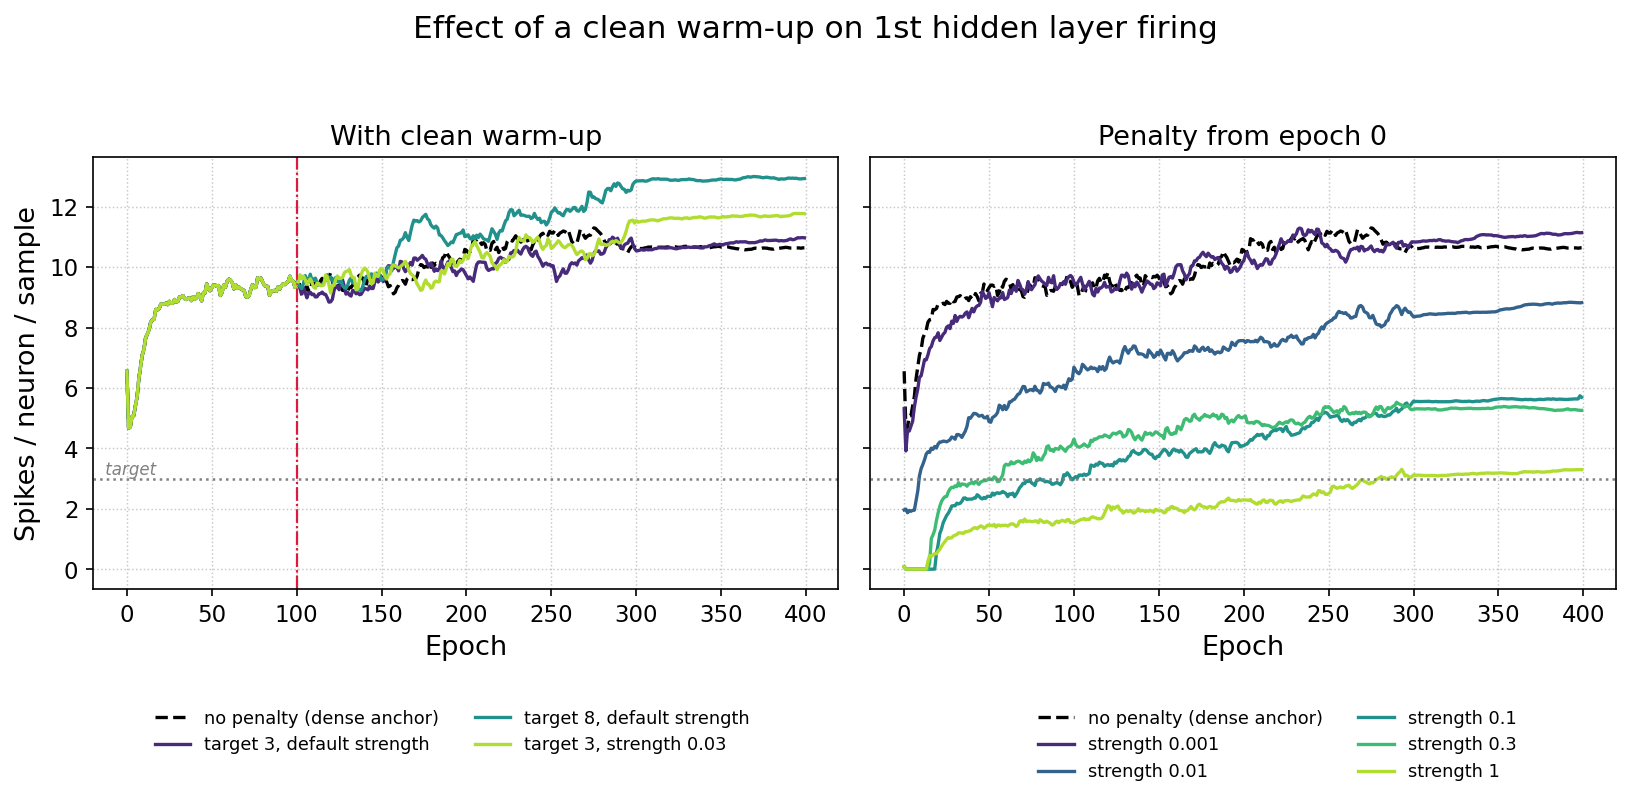

In [4]:
plot_warmup_comparison(
    "Effect of a clean warm-up on 1st hidden layer firing",
)

## 4. Attempt 1 — plain L1 collapses under Nadam

`λ · Σ spikes` applied from epoch 0. Every λ from 1e-4 to 1e-2 silences the hidden
layer within one epoch: firing goes to 0, the task loss pins at its no-spike value,
the delays never train and accuracy sits at chance. The five curves coincide
exactly, so they are drawn with tapering line widths to keep each visible.
Recovery is impossible because a silent neuron has no surrogate gradient — which
is what motivated the one-sided hinge, whose gradient vanishes at or below the
target instead.

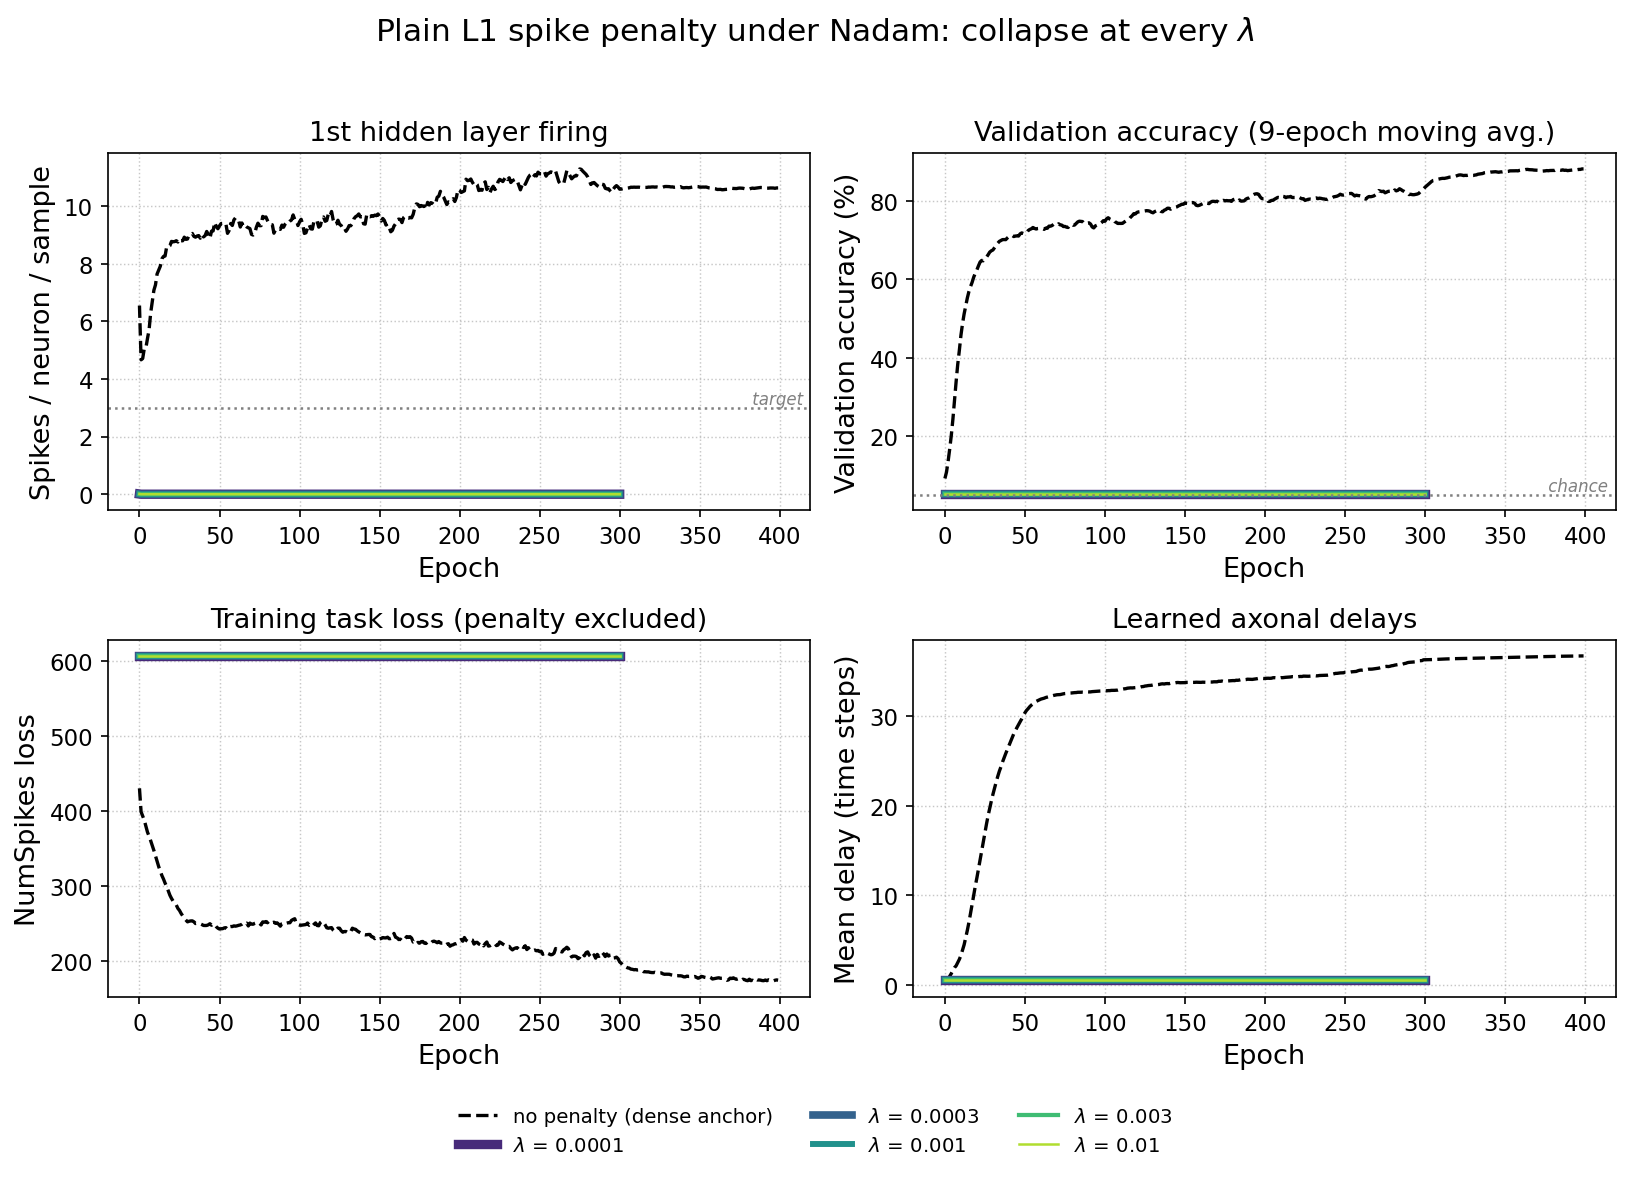

In [5]:
l1_runs = select_runs("l1")

plot_training_grid(
    # The five curves coincide exactly, so taper the width to keep each visible.
    series=build_series(
        l1_runs,
        lambda run: f"$\\lambda$ = {run.lam:g}",
        index_colors(len(l1_runs)),
        linewidths=np.linspace(4.5, 1.2, len(l1_runs)),
    ),
    suptitle="Plain L1 spike penalty under Nadam: collapse at every $\\lambda$",
    anchor=anchor_run(),
)

## Run inventory

Every log in the folder, with the provenance the figures separate on: which
penalty family it belongs to, its coefficient, and the warm-up length recovered
from its curves.

In [6]:
print_run_inventory()

run                   penalty     coeff  warm-up  epochs   firing  best val %  clean test %
-------------------------------------------------------------------------------------------
lam0.0001             l1         0.0001        0     301     0.00        5.14             -
lam0.0003             l1         0.0003        0     301     0.00        5.14             -
lam0.001              l1          0.001        0     301     0.00        5.14             -
lam0.003              l1          0.003        0     301     0.00        5.14             -
lam0.01               l1           0.01        0     301     0.00        5.14             -
lam0                  none            -        -     400    10.63       88.65             -
tgt3                  hinge           -      100     400    10.95       89.12             -
tgt3_str0.001         hinge       0.001        0     400    11.13       89.12             -
tgt3_str0.01          hinge        0.01        0     400     8.83       87.32   